# Ejercicio Tema 1: Análisis exploratorio de datos y visualización con matplotlib/seaborn

### Juan Alcaraz, José Aguilar, Óscar Camacho, Adrián Carrasco, Javier Herrero, Clara Montalvá 

## 1. Preprocesado y estadística descriptiva

En primer lugar, importamos el dataset y lo preprocesamos.

In [3]:
# Dataset : Arritmias.csv

import pandas as pd
import numpy as np

df_raw = pd.read_csv("data/Arritmias.csv")
cols = df_raw.columns[1:-4]

# Preproceso: 
#  a) cambiar separador decimal (, por .)
#  b) re-etiquetar AV como clase binaria (0/1)

# Cambio , por . en las series de excel formated_df: fdf
df = df_raw.copy()

for i in range(len(cols)):
      df[cols[i]] = df[cols[i]].str.replace(",", ".").astype(float)

cols = df.columns[1:-1]
X = df[cols].to_numpy()  # Marcadores de arritmia post-infarto
Y = df['AV'].to_numpy()  # AV: Arritmia Ventricular

print(df.head())

# Estudiar los 2 grupos de pacientes suministrados:  AV = 0 (no presenta arritmia) y AV = 1 (presenta arritmia)  
# Analizar y representar gráficamente la influencia de los marcadores suministrados en ambos grupos.
# Escribir un pequeño informe con el resumen de las gráficas generadas y las principales conclusiones extraídas (2-3 pp).

# Descripción de los marcadores utilizados :

# LV Mass(g)                : masa en gramos del ventrículo izquierdo.
# BZ+Core (g)               : masa en gramos de la zona infartada (core) + su borde (BZone)
# BZ (g, %)                 : masa en gramos de la zona de borde y su porcentaje
# Core (g, %)               : masa en gramos de la zona infartada y su porcentaje
# Channel_Mass (g)          : masa en gramos de los canales encontrados
# LVEF                      : fuerza de eyección del ventrículo
# Edad, Sexo
# AV                        : presenta arrimia (1), no presenta arritmia (0)


  PACIENTES  LV MASS (g)  BZ + CORE (g)  BZ + CORE (%)  BZ (g)  BZ (%)  \
0        P1        82.18           5.10           6.21    4.45    5.41   
1        P2       109.10          16.84          15.43   13.36   12.25   
2        P3       100.88           5.17           5.12    4.65    4.61   
3        P4        67.81           5.18           7.64    3.50    5.16   
4        P5       197.65          47.57          24.07   42.21   21.36   

   CORE (g)  CORE (%)  CHANNEL MASS (g)  LVEF  EDAD  SEXO  AV  
0      0.64      0.78              0.00    66    71     1   0  
1      3.48      3.19              8.05    36    53     1   1  
2      0.51      0.51              0.00    61    63     1   0  
3      2.48      3.66              2.37    63    74     2   0  
4      5.36      2.71             21.09    28    84     1   1  


Definimos los parámetros estilísticos que utilizaremos en todas las gráficas.

In [11]:
np.random.seed(42)
import seaborn as sns

COLOR_AV0  = '#4C72B0'   # sin arritmia
COLOR_AV1  = '#DD8452'   # con arritmia
PALETTE    = {0: COLOR_AV0, 1: COLOR_AV1}
LABEL_AV0  = 'AV=0 (sin arritmia)'
LABEL_AV1  = 'AV=1 (con arritmia)'

sns.set_theme(style='whitegrid', font_scale=1.05)

A continuación, obtenemos estadísticas descriptivas por grupos.

In [6]:
df0 = df[df['AV'] == 0]
df1 = df[df['AV'] == 1]

stats_rows = []
for col in df_raw.columns[1:-3]:
    for av, grupo in [(0, df0), (1, df1)]:
        s = grupo[col]
        stats_rows.append({
            'Marcador': col, 'Grupo': f'AV={av}',
            'N': len(s), 'Media': round(s.mean(), 3),
            'Desv.Típica': round(s.std(), 3),
            'Mín': round(s.min(), 3), 'P25': round(s.quantile(.25), 3),
            'Mediana': round(s.median(), 3), 'P75': round(s.quantile(.75), 3),
            'Máx': round(s.max(), 3)
        })

desc_df = pd.DataFrame(stats_rows).set_index(['Marcador', 'Grupo'])
print('Estadística Descriptiva por Grupo')
display(desc_df)

Estadística Descriptiva por Grupo


N    Media  Desv.Típica    Mín      P25  Mediana  \
Marcador         Grupo                                                      
LV MASS (g)      AV=0   39  111.044       31.164  60.24   88.190  107.160   
                 AV=1   12  138.563       36.486  99.52  108.310  130.855   
BZ + CORE (g)    AV=0   39   18.344       19.017   0.34    6.260   11.690   
                 AV=1   12   34.699       28.190   4.77   17.335   24.700   
BZ + CORE (%)    AV=0   39   14.977       12.027   0.42    6.395   12.250   
                 AV=1   12   22.921       13.705   4.80   14.497   17.605   
BZ (g)           AV=0   39   13.439       12.666   0.27    4.585    8.100   
                 AV=1   12   24.172       17.572   3.45   13.660   16.525   
BZ (%)           AV=0   39   11.223        8.491   0.33    4.735    8.940   
                 AV=1   12   16.091        8.246   3.47   10.730   12.880   
CORE (g)         AV=0   39    5.001        7.209   0.07    1.025    3.430   
                 AV=1   12   10.528       11.573   1.15    3.142    5.460   
CORE (%)         AV=0   39    3.855        4.491   0.09    1.085    3.170   
                 AV=1   12    6.832        5.986   1.14    2.388    4.525   
CHANNEL MASS (g) AV=0   39    5.503        8.247   0.00    0.590    2.020   
                 AV=1   12    9.126        7.484   0.00    3.502    8.555   
LVEF             AV=0   39   52.000       11.943  30.00   42.500   55.000   
                 AV=1   12   41.167       10.803  28.00   34.250   37.500   

                            P75     Máx  
Marcador         Grupo                   
LV MASS (g)      AV=0   121.860  195.69  
                 AV=1   157.502  206.77  
BZ + CORE (g)    AV=0    22.450   88.61  
                 AV=1    48.600  106.50  
BZ + CORE (%)    AV=0    19.545   51.83  
                 AV=1    32.935   51.50  
BZ (g)           AV=0    18.350   53.20  
                 AV=1    34.705   65.73  
BZ (%)           AV=0    15.305   32.26  
                 AV=1    21.462   31.79  
CORE (g)         AV=0     4.775   35.41  
                 AV=1    13.295   40.76  
CORE (%)         AV=0     4.955   21.51  
                 AV=1    10.938   19.71  
CHANNEL MASS (g) AV=0     8.180   35.19  
                 AV=1    11.505   22.97  
LVEF             AV=0    62.500   72.00  
                 AV=1    49.000   59.00

Por último, realizamos un Test de Mann-Whitney U por marcador.

In [8]:
from scipy.stats import mannwhitneyu

def significance_label(p):
    if p < 0.001: return '*'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

mw_results = []
pvalues = {}
for col in df_raw.columns[1:-3]:
    stat, p = mannwhitneyu(df0[col].dropna(), df1[col].dropna(),
                           alternative='two-sided')
    pvalues[col] = p
    mw_results.append({
        'Marcador': col, 'U-statistic': round(stat, 2),
        'p-value': round(p, 5), 'Significancia': significance_label(p)
    })

mw_df = pd.DataFrame(mw_results).sort_values('p-value').set_index('Marcador')
print('Test Mann-Whitney U – Diferencias entre AV=0 y AV=1')
display(mw_df)

sig_markers = [c for c in df_raw.columns[1:-3] if pvalues[c] < 0.05]
print(f'\nMarcadores significativos (p<0.05): {sig_markers}')

top5_markers = list(mw_df.head(5).index)

Test Mann-Whitney U – Diferencias entre AV=0 y AV=1


,U-statistic,p-value,Significancia
Marcador,,,
LVEF,356.0,0.00693,**
LV MASS (g),126.0,0.01698,*
BZ (g),132.0,0.02420,*
CORE (g),136.0,0.03037,*
BZ + CORE (g),136.0,0.03038,*
BZ + CORE (%),145.0,0.04939,*
CHANNEL MASS (g),146.5,0.05247,
BZ (%),152.0,0.07033,
CORE (%),155.5,0.08324,



Marcadores significativos (p<0.05): ['LV MASS (g)', 'BZ + CORE (g)', 'BZ + CORE (%)', 'BZ (g)', 'CORE (g)', 'LVEF']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind
import warnings
warnings.filterwarnings('ignore')

# ── Paleta y estilo globales ──────────────────────────────────────────────────
COLOR_AV0  = '#4C72B0'   # azul  → sin arritmia
COLOR_AV1  = '#DD8452'   # naranja → con arritmia
PALETTE    = {0: COLOR_AV0, 1: COLOR_AV1}
LABEL_AV0  = 'AV=0 (sin arritmia)'
LABEL_AV1  = 'AV=1 (con arritmia)'

sns.set_theme(style='whitegrid', font_scale=1.05)

In [ ]:
# ── 1.1 Lectura del CSV ───────────────────────────────────────────────────────
df_raw = pd.read_csv('data/Arritmias.csv')

# ── 1.2 Identificación de columnas ───────────────────────────────────────────
# Columnas numéricas con coma decimal (todas salvo PACIENTES, SEXO, EDAD, AV)
comma_cols = ['LV MASS (g)', 'BZ + CORE (g)', 'BZ + CORE (%)',
              'BZ (g)', 'BZ (%)', 'CORE (g)', 'CORE (%)', 'CHANNEL MASS (g)']

# Variables demográficas y target
demo_cols   = ['EDAD', 'SEXO']
target_col  = 'AV'

# Marcadores cardíacos (los que se analizarán con Mann-Whitney)
marker_cols = comma_cols + ['LVEF']

# ── 1.3 Conversión a float (reemplazar coma decimal por punto) ────────────────
df = df_raw.copy()
for col in comma_cols:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

# Asegurar tipos numéricos en el resto
df['LVEF'] = pd.to_numeric(df['LVEF'], errors='coerce')
df['EDAD'] = pd.to_numeric(df['EDAD'], errors='coerce')
df['SEXO'] = pd.to_numeric(df['SEXO'], errors='coerce')   # 1=Hombre, 2=Mujer
df['AV']   = pd.to_numeric(df['AV'],   errors='coerce').astype(int)

# Separar grupos
df0 = df[df['AV'] == 0]
df1 = df[df['AV'] == 1]

print(f'Total pacientes: {len(df)}  |  AV=0: {len(df0)}  |  AV=1: {len(df1)}')
print('\nPrimeras filas:')
df.head()

In [ ]:
# ── 1.4 Estadística descriptiva por grupo ─────────────────────────────────────
stats_rows = []
for col in marker_cols:
    for av, grupo in [(0, df0), (1, df1)]:
        s = grupo[col]
        stats_rows.append({
            'Marcador': col, 'Grupo': f'AV={av}',
            'N': len(s), 'Media': round(s.mean(), 3),
            'Desv.Típica': round(s.std(), 3),
            'Min': round(s.min(), 3), 'P25': round(s.quantile(.25), 3),
            'Mediana': round(s.median(), 3), 'P75': round(s.quantile(.75), 3),
            'Max': round(s.max(), 3)
        })

desc_df = pd.DataFrame(stats_rows).set_index(['Marcador', 'Grupo'])
print('=== Estadística Descriptiva por Grupo ===')
display(desc_df)

In [ ]:
# ── 1.5 Test Mann-Whitney U por marcador ──────────────────────────────────────
def significance_label(p):
    if p < 0.001: return '*'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

mw_results = []
pvalues = {}   # guardamos para anotaciones en figuras
for col in marker_cols:
    stat, p = mannwhitneyu(df0[col].dropna(), df1[col].dropna(),
                           alternative='two-sided')
    pvalues[col] = p
    mw_results.append({
        'Marcador': col, 'U-statistic': round(stat, 2),
        'p-value': round(p, 5), 'Significancia': significance_label(p)
    })

mw_df = pd.DataFrame(mw_results).sort_values('p-value').set_index('Marcador')
print('=== Test Mann-Whitney U – Diferencias entre AV=0 y AV=1 ===')
display(mw_df)

# Marcadores significativos
sig_markers = [c for c in marker_cols if pvalues[c] < 0.05]
print(f'\nMarcadores significativos (p<0.05): {sig_markers}')

# Top-5 marcadores (menor p-value) para Figura 3
top5_markers = list(mw_df.head(5).index)

## 2. Figura 1 – Distribuciones por marcador (Violin + Box + Strip)

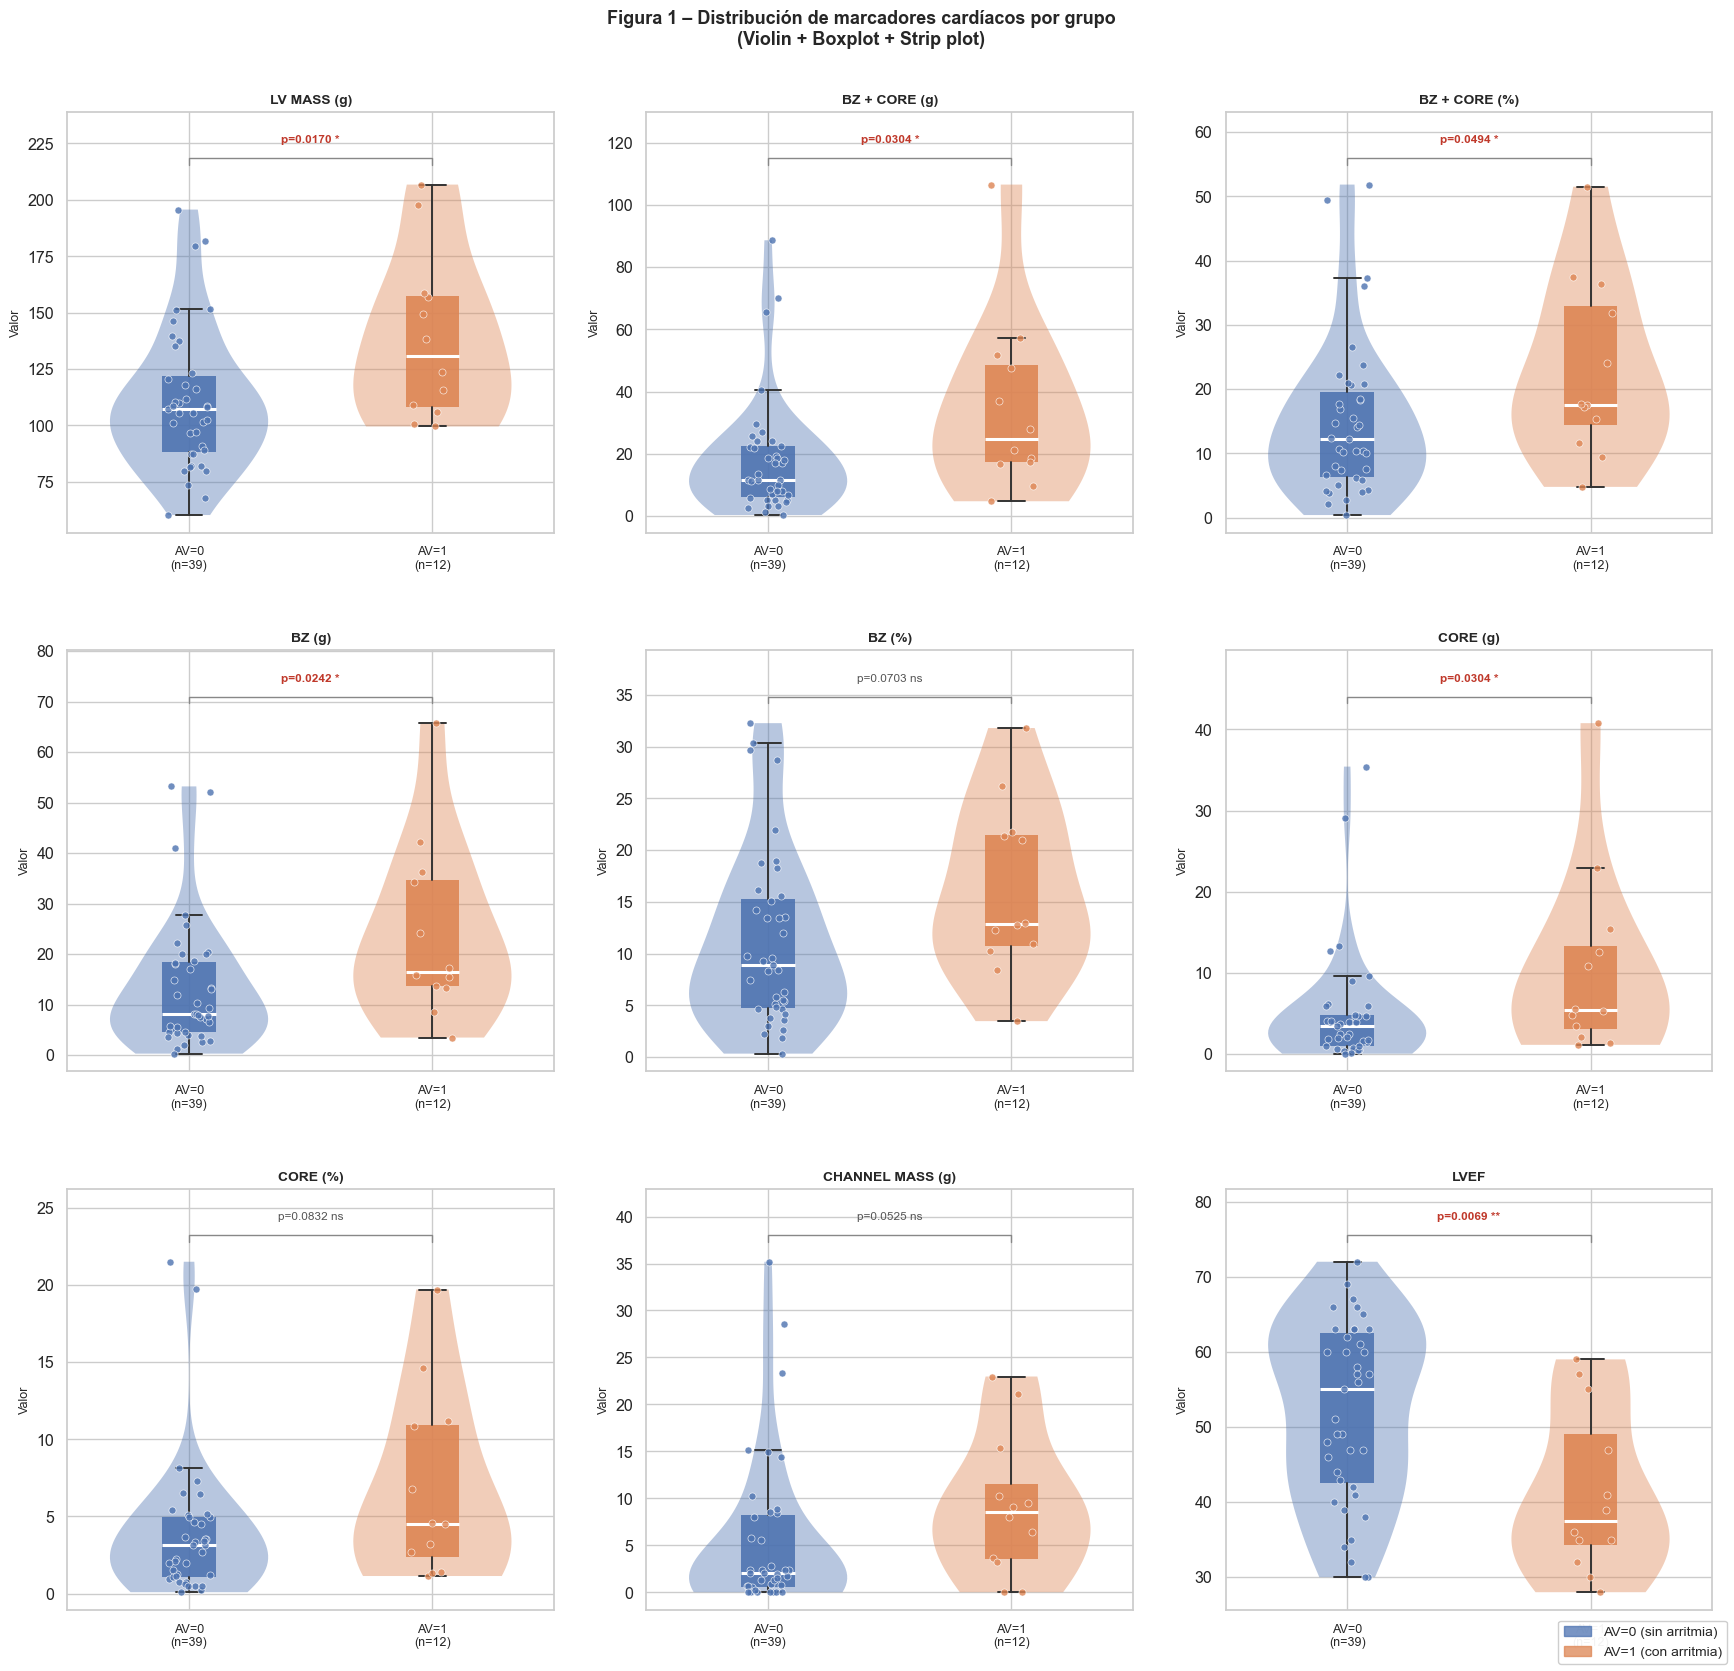

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

n_cols = 3
n_rows = int(np.ceil(len(df_raw.columns[1:-3]) / n_cols))
fig1, axes = plt.subplots(n_rows, n_cols, figsize=(5.8 * n_cols, 5.5 * n_rows))
axes = axes.flatten()

def sig_label(p):
    if p < 0.001: return '*'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

for idx, col in enumerate(df_raw.columns[1:-3]):
    ax = axes[idx]
    d0 = df0[col].dropna().values
    d1 = df1[col].dropna().values

    # Violin
    vp = ax.violinplot([d0, d1], positions=[0, 1], widths=0.65,
                       showmeans=False, showmedians=False, showextrema=False)
    for body, color in zip(vp['bodies'], [COLOR_AV0, COLOR_AV1]):
        body.set_facecolor(color); body.set_alpha(0.40); body.set_edgecolor('none')

    # Boxplot sin notches (evita artefactos con n=12)
    bp = ax.boxplot([d0, d1], positions=[0, 1], widths=0.22, notch=False,
                    patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.2),
                    whiskerprops=dict(linewidth=1.4, color='#333333'),
                    capprops=dict(linewidth=1.4, color='#333333'),
                    flierprops=dict(marker='', markersize=0),
                    boxprops=dict(linewidth=0))
    for patch, color in zip(bp['boxes'], [COLOR_AV0, COLOR_AV1]):
        patch.set_facecolor(color); patch.set_alpha(0.88)

    # Strip plot (jitter)
    for xpos, datos, color in [(0, d0, COLOR_AV0), (1, d1, COLOR_AV1)]:
        jitter = np.random.uniform(-0.09, 0.09, size=len(datos))
        ax.scatter(xpos + jitter, datos, color=color, alpha=0.80, s=26,
                   zorder=4, edgecolors='white', linewidths=0.5)

    # Título limpio
    ax.set_title(col, fontsize=10, fontweight='bold', pad=6)

    # Anotación p-value con línea de significancia entre grupos
    p = pvalues[col]
    sig = sig_label(p)
    color_sig = '#c0392b' if p < 0.05 else '#555555'
    y_max = max(d0.max(), d1.max())
    y_rng = y_max - min(d0.min(), d1.min())
    y_line = y_max + y_rng * 0.08
    y_text = y_line + y_rng * 0.04
    ax.plot([0, 0, 1, 1],
            [y_line - y_rng*0.02, y_line, y_line, y_line - y_rng*0.02],
            color='#888888', linewidth=1.0)
    ax.text(0.5, y_text, f'p={p:.4f} {sig}',
            ha='center', va='bottom', fontsize=8.5,
            color=color_sig, fontweight='bold' if p < 0.05 else 'normal')
    ax.set_ylim(top=y_text + y_rng * 0.10)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['AV=0\n(n=39)', 'AV=1\n(n=12)'], fontsize=9)
    ax.set_ylabel('Valor', fontsize=9)

for ax in axes[len(df_raw.columns[1:-3]):]:
    ax.set_visible(False)

patch0 = mpatches.Patch(color=COLOR_AV0, label=LABEL_AV0, alpha=0.75)
patch1 = mpatches.Patch(color=COLOR_AV1, label=LABEL_AV1, alpha=0.75)
fig1.legend(handles=[patch0, patch1], loc='lower right', fontsize=10,
            framealpha=0.95, edgecolor='#cccccc')
fig1.suptitle('Figura 1 – Distribución de marcadores cardíacos por grupo\n(Violin + Boxplot + Strip plot)',
              fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout(h_pad=3.5, w_pad=2.0)
plt.show()

*Marcadores significativos (p < 0,05):*

Los 6 marcadores significativos comparten un patrón visual común: los violines de ambos grupos están *desplazados verticalmente* con escaso solapamiento entre sus cuerpos principales, y los boxplots tienen medianas claramente separadas. El caso más extremo es *LVEF* (p = 0,0069, \\), donde los dos violines prácticamente no se tocan: AV=0 concentra su masa en 50–65% y AV=1 en 30–50%. En el extremo opuesto, *BZ + CORE (%)* (p = 0,0494, \*) está justo en el límite porque, aunque la tendencia existe, los violines comparten una zona de solapamiento amplia en torno al 10–25%, lo que reduce la confianza del test.

*Marcadores no significativos (p ≥ 0,05):*

Los 3 marcadores no significativos tienen en común que sus violines *se solapan extensamente* y los puntos del strip de AV=0 alcanzan los mismos valores máximos que AV=1. En *BZ (%)* y *CORE (%)* la causa es la alta dispersión interna de AV=0, cuyos violines tienen colas superiores largas que invaden el rango de AV=1. En *CHANNEL MASS (g)* (p = 0,0525, ns) hay un caso especialmente ilustrativo: existe un único outlier en AV=0 visible en el strip plot en torno a 35 g que estira el violin hacia arriba artificialmente, inflando la varianza del grupo y elevando el p-value por encima del umbral. Sin ese punto atípico, este marcador probablemente resultaría significativo.

*Patrón general:*

Los marcadores en *gramos absolutos* son sistemáticamente más significativos que los *porcentuales*. Esto indica que lo clínicamente relevante es la cantidad absoluta de tejido dañado: un paciente con un ventrículo grande puede tener un porcentaje de infarto moderado pero una masa necrótica en gramos suficientemente elevada como para generar el sustrato arrítmico.

## 3. Figura 2 – Heatmap de correlaciones por grupo

## 4. Figura 3 – Pairplot de marcadores más discriminantes

## 5. Figura 4 – Variables demográficas (Edad y Sexo) vs AV

## 6. Figura 5 – Radar chart (Perfil medio normalizado)

In [ ]:
# Vemos según el p-value que 'LV MASS (g)' y 'LVEF' son los más discriminantes
top_2 = ['LV MASS (g)', 'LVEF']

plt.figure(figsize=(10, 7))

# Hacemos un scatter plot coloreado por grupo
sns.scatterplot(data=df, x='LV MASS (g)', y='LVEF', hue='AV', palette=PALETTE, alpha=0.6)

# Superponer contornos KDE 
sns.kdeplot(data=df, x='LV MASS (g)', y='LVEF', hue='AV', palette=PALETTE, levels=5, alpha=0.5)

plt.title("Figura 6: 'LV MASS (g)' vs 'LVEF'")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 7. Figura 6 – Scatter + Contornos KDE

## 8. Informe escrito